/var/folders/x9/wd_qfshj499fqs74_wrvx5y40000gn/T/ipykernel_39981/2607814124.py:12: DtypeWarning: Columns (558) have mixed types. Specify dtype option on import or set low_memory=False.
  result_question = pd.read_csv('/Users/dylanchen/Desktop/geek-community/Archive/result_question.csv')
/var/folders/x9/wd_qfshj499fqs74_wrvx5y40000gn/T/ipykernel_39981/2607814124.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')


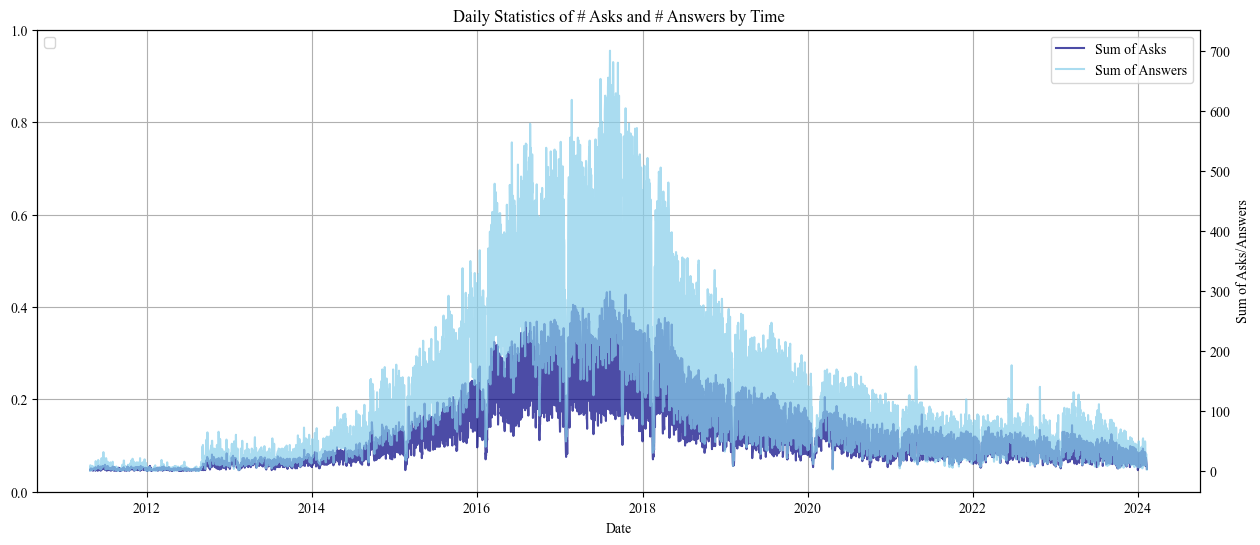

In [7]:
# 描述性统计
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

start_date = '2001-01-01'
end_date = '2024-12-31'

cmn_base = pd.read_csv("/Users/dylanchen/Desktop/geek-community/panel_factory/data/raw/cmn_base.csv")
result_question = pd.read_csv('/Users/dylanchen/Desktop/geek-community/Archive/result_question.csv')
cmn_base['date'] = pd.to_datetime(cmn_base['date'])
cmn_base['date'] = cmn_base['date'].dt.normalize()
result_question['date'] = pd.to_datetime(result_question['date'])
result_question['date'] = result_question['date'].dt.normalize()

# Filter data based on the start and end dates
filtered_cmn_base = cmn_base[(cmn_base['date'] >= start_date) & (cmn_base['date'] <= end_date)]
filtered_result_question = result_question[(result_question['date'] >= start_date) & (result_question['date'] <= end_date)]

# Group by date and calculate the daily average of wait1Resp
data_askSum = filtered_cmn_base.groupby('date')['ask'].sum()
data_answerSum = filtered_cmn_base.groupby('date')['answer'].sum()
data_wait1RespAvf = filtered_result_question.groupby('date')['wait1Resp'].mean()
data_geekAsk = filtered_result_question.groupby('date')['geekAsk'].mean()

# Plot the chart
# Plotting with a separate Y-axis for date_wait1RespAvf

plt.figure(figsize=(15, 6), dpi=100)

# Create a secondary y-axis for the wait1Resp average
ax1 = plt.gca()
ax2 = ax1.twinx()
# ax3 = ax2.twinx()

# # Plotting on the primary/secondary y-axis
# ax1.plot(data_wait1RespAvf, label='Average wait1Resp', color='blue', zorder=100)
ax2.plot(data_askSum, label='Sum of Asks', color='navy', alpha=0.7)
ax2.plot(data_answerSum, label='Sum of Answers', color='skyblue', alpha=0.7)
# ax2.plot(data_answerSum, label='Sum of Answers', color='skyblue', alpha=0.7)
# ax3.plot(data_geekAsk, label='Sum of Answers', color='red', alpha=0.7)

# Adding labels and title
ax1.set_xlabel('Date')
# ax1.set_ylabel('Average wait1Resp')
ax2.set_ylabel('Sum of Asks/Answers')
# ax3.set_ylabel('Average geekAsk')
plt.title('Daily Statistics of # Asks and # Answers by Time')

# # Drawing the bracket
# final_sample_start_dt = pd.to_datetime('2017-01-01')
# final_sample_end_dt = pd.to_datetime('2023-12-31')
# ax2.annotate('', xy=(final_sample_start_dt, ax2.get_ylim()[1]*0.68), xytext=(final_sample_end_dt, ax2.get_ylim()[1]*0.68),
#              arrowprops=dict(arrowstyle='<->', lw=2))
# # Adding text for the bracket
# mid_point = final_sample_start_dt + (final_sample_end_dt - final_sample_start_dt) / 2
# ax2.text(mid_point, ax2.get_ylim()[1]*0.7, 'Final Analysis Sample', ha='center')


# Adding legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Adding grid
ax1.grid(True)

# Show plot
# plt.savefig('./sample_plot.png')
plt.show()

